## Libraries

In [1]:
import torch
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import time

## Section 1

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s] 


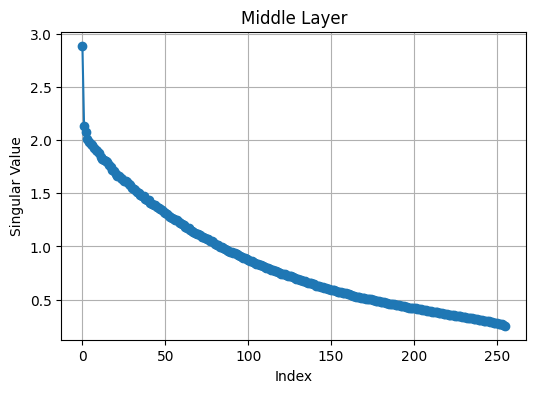

Middle Layer
Total singular values: 256
Singular values for 95% variance: 173
Keep: 67.58%


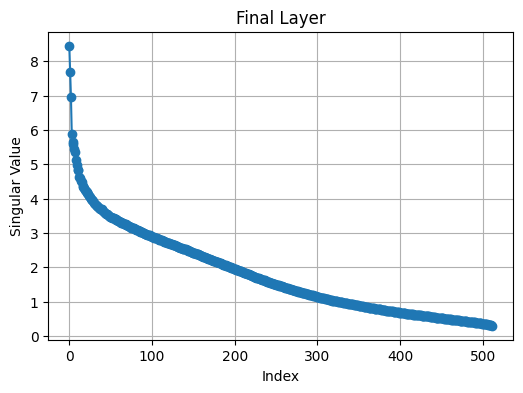

Final Layer
Total singular values: 512
Singular values for 95% variance: 291
Keep: 56.84%


In [2]:
# Load DataSet
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.eval()

# Middle and Final Layer
middle_layer = model.layer3[0].conv1.weight.data.cpu().numpy()
final_layer = model.fc.weight.data.cpu().numpy()

# Build Matrix
middle_layer_matrix = middle_layer.reshape(middle_layer.shape[0], -1)

def spectral_analysis(W, name):
    U, S, Vt = np.linalg.svd(W, full_matrices=False)
    variance = S**2
    cumulative_variance = np.cumsum(variance) / np.sum(variance)

    k95 = np.argmax(cumulative_variance >= 0.95) + 1

    plt.figure(figsize=(6,4))
    plt.plot(S, marker='o')
    plt.xlabel("Index")
    plt.ylabel("Singular Value")
    plt.title(f"{name}")
    plt.grid(True)
    plt.savefig(f"{name}.pdf")
    plt.show()
    
    print(f"{name}")
    print(f"Total singular values: {len(S)}")
    print(f"Singular values for 95% variance: {k95}")
    print(f"Keep: {100*k95/len(S):.2f}%")

spectral_analysis(middle_layer_matrix, "Middle Layer")
spectral_analysis(final_layer, "Final Layer")


## Section 2

In [3]:
device = "cpu"

# Low-rank 
def low_rank_linear(layer, rank_ratio):
    W = layer.weight.data
    b = layer.bias.data

    U, S, V = torch.linalg.svd(W, full_matrices=False)
    k = int(rank_ratio * S.numel())

    first = nn.Linear(W.shape[1], k, bias=False)
    second = nn.Linear(k, W.shape[0], bias=True)

    first.weight.data = V[:k, :]
    second.weight.data = U[:, :k] @ torch.diag(S[:k])
    second.bias.data = b

    return nn.Sequential(first, second)

# Accuracy 
def accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return 100 * correct / total

# Data 
transform = transforms.Compose([transforms.Resize(64), transforms.ToTensor()])

testset = datasets.CIFAR10("./data", train=False, transform=transform, download=True)
testset = Subset(testset, range(1000))  
testloader = DataLoader(testset, batch_size=32)

# Models
configs = {
    "Original": 1.0,
    "50% Rank": 0.5,
    "80% Rank": 0.2
}

for name, r in configs.items():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(512, 10)  

    if r < 1.0:
        model.fc = low_rank_linear(model.fc, r)

    acc = accuracy(model, testloader)
    params = sum(p.numel() for p in model.parameters())

    print(f"{name}: Accuracy = {acc:.2f}%, Params = {params:,}")

100%|██████████| 170M/170M [00:02<00:00, 82.9MB/s] 


Original: Accuracy = 9.00%, Params = 11,181,642
50% Rank: Accuracy = 10.50%, Params = 11,179,132
80% Rank: Accuracy = 9.70%, Params = 11,177,566


## Section 3

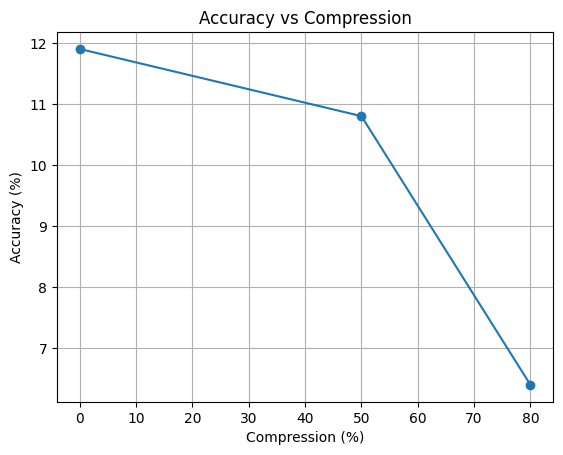

Accuracies: [11.9, 10.8, 6.4]
Times: [0.0255124568939209, 0.011168718338012695, 0.009226322174072266]


In [4]:
# One-batch
def finetune_one_batch(model, loader):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    x, y = next(iter(loader))
    opt.zero_grad()
    loss = loss_fn(model(x), y)
    loss.backward()
    opt.step()

# Train/Test
trainset = datasets.CIFAR10("./data", train=True, transform=transform, download=True)
trainset = Subset(trainset, range(1000))

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)

rates = [1.0, 0.5, 0.2]
accs, times = [], []

for r in rates:
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(512, 10)

    if r < 1.0:
        model.fc = low_rank_linear(model.fc, r)

    # Fine-tune 
    finetune_one_batch(model, trainloader)

    # Accuracy
    accs.append(accuracy(model, testloader))
    
    x, _ = next(iter(testloader))
    x = x[:1]
    start = time.time()
    model(x)
    times.append(time.time() - start)

# Plot
plt.plot([0, 50, 80], accs, marker='o')
plt.xlabel("Compression (%)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Compression")
plt.grid()
plt.savefig("AccComp.pdf")
plt.show()

print("Accuracies:", accs)
print("Times:", times)
